# Practical Statistics for Data Scientists (Python)
# Chapter 1. Exploratory Data Analysis
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

**Reproduksi dan pembahasan:** Nanda Pratama ITM · NIM 101032330212 · TK 47 01.

Kode diadaptasi dari repositori resmi Peter Bruce, Andrew Bruce, dan Peter Gedeck (GPL-3.0); bukan klaim kode orisinal mahasiswa. Penjelasan Indonesia dan eksperimen tambahan disusun dengan bantuan AI. Sumber serta koreksi tercatat pada README dan docs/PERUBAHAN.md.

## Petunjuk penggunaan dan sumber

Baca teori berikut, kemudian jalankan sel kode berurutan dari atas ke bawah. Bagian **Reproduksi kode buku** mempertahankan semua sel Python nonkosong sumber resmi dengan koreksi yang dicatat. Bagian **Eksperimen tambahan** adalah pengembangan edukatif. Notebook gabungan ini telah dijalankan berurutan pada kernel baru, termasuk eksperimen tambahan.

Referensi utama: Bruce, Bruce, & Gedeck (2020), *Practical Statistics for Data Scientists*, edisi ke-2. [Kode resmi](https://github.com/gedeck/practical-statistics-for-data-scientists), commit `8a6d3bb6468e979c861d4b37215e1413702dfdfa`. Lihat [catatan perubahan](../docs/PERUBAHAN.md).

# Ringkasan dan pendalaman teori Bab 1

Bab ini membangun kebiasaan memahami bentuk, pusat, sebaran, dan hubungan data sebelum membuat model. EDA membantu mendeteksi kesalahan pencatatan, nilai ekstrem, kategori jarang, serta kebutuhan transformasi. Contoh negara bagian AS, keterlambatan penerbangan, saham, pinjaman, dan properti menunjukkan bahwa jenis variabel menentukan cara analisis.


## Jenis data dan struktur tabel
Data numerik dapat kontinu (luas rumah) atau diskret (jumlah kamar). Kategori dapat nominal (maskapai), ordinal (grade pinjaman), atau biner (gagal bayar). Angka kode pos adalah label, sehingga rata-rata kode pos tidak bermakna. Pada data persegi panjang, satu baris adalah unit pengamatan dan satu kolom adalah variabel. Indeks mengidentifikasi baris; indeks tidak otomatis layak menjadi prediktor. Teks, citra, graf, dan deret waktu membutuhkan representasi tambahan. Unit pengamatan dan waktu pencatatan harus jelas untuk menghindari duplikasi serta kebocoran informasi.


## Ukuran lokasi
Rata-rata $\bar{x}=\sum_i x_i/n$ memakai semua nilai sehingga sensitif terhadap pencilan. Median membagi observasi terurut menjadi dua bagian dan lebih tahan nilai ekstrem. Trimmed mean membuang proporsi tertentu di kedua ekor; `trim_mean(x, 0.1)` membuang 10% dari masing-masing sisi, bukan 10% keseluruhan. Mean populasi negara bagian lebih besar daripada median bila beberapa negara bagian sangat besar.

Rata-rata berbobot $\bar{x}_w=\sum_iw_ix_i/\sum_iw_i$ membedakan kontribusi observasi. Membobot tingkat pembunuhan dengan populasi menjawab pertanyaan untuk penduduk agregat; rata-rata tak berbobot memberi bobot sama kepada negara bagian. Weighted median membagi jumlah bobot menjadi dua. Pembobotan harus sesuai unit sasaran, bukan dipilih untuk mendapatkan angka tertentu.


## Variabilitas dan ukuran robust
Varians sampel $s^2=\sum_i(x_i-\bar{x})^2/(n-1)$ mengukur penyimpangan kuadrat. Simpangan baku s kembali ke satuan asal. Penyebut n-1 mengoreksi estimasi ketika mean populasi diganti mean sampel. IQR adalah $Q_{0.75}-Q_{0.25}$, yaitu rentang 50% tengah. MAD mentah adalah $\operatorname{median}|x_i-\operatorname{median}(x)|$.

`statsmodels.robust.scale.mad` membagi MAD mentah dengan sekitar 0.67449 secara default. Hasilnya konsisten dengan simpangan baku pada distribusi normal, sehingga jangan menyamakannya dengan MAD mentah tanpa menyebut normalisasi. Simpangan baku besar bersama IQR kecil dapat menandakan ekor berat. Robust tidak berarti semua pencilan harus dibuang: kesalahan input dan kejadian ekstrem yang valid perlu dibedakan.


## Kuantil, boxplot, histogram, dan density
Persentil adalah batas posisi pada distribusi terurut. Boxplot memperlihatkan median dan kuartil. Whisker biasanya mencapai observasi terakhir dalam 1.5 IQR dari kuartil; titik di luarnya adalah kandidat pencilan, bukan bukti kesalahan. Histogram menghitung frekuensi per interval; bentuknya sensitif pada batas dan jumlah bin. Density plot memperkirakan kepadatan melalui kernel. Luas di bawah kurva density adalah satu; tinggi pada suatu titik kontinu bukan probabilitas di titik itu. Bandwidth kecil menampilkan detail sekaligus noise; bandwidth besar dapat menyamarkan beberapa puncak.


## Kategorikal, modus, nilai harapan, dan peluang
Tabel frekuensi dan diagram batang merangkum kategori. Modus adalah kategori paling sering, dan tidak selalu unik. Nilai harapan $E(X)=\sum_xxP(X=x)$ menggabungkan nilai numerik dengan peluangnya; ini berbeda dari modus. Proporsi empiris mengestimasi peluang jika pengambilan data sesuai populasi sasaran. Penyebab keterlambatan yang paling sering belum tentu penyebab dengan total durasi terlama: definisi denominator dan metrik harus diperiksa.


## Korelasi dan scatterplot
Pearson $r=\sum_i(x_i-\bar{x})(y_i-\bar{y})/[(n-1)s_xs_y]$ mengukur hubungan linear, antara -1 dan 1 bila kedua varians positif. Korelasi nol tidak meniadakan hubungan nonlinear; korelasi tinggi tidak membuktikan sebab-akibat. Scatterplot mengungkap bentuk hubungan, kelompok, dan pencilan yang tersembunyi oleh satu koefisien. Heatmap membantu membandingkan banyak pasangan. Korelasi perubahan saham berlaku pada periode yang dipilih dan bukan jaminan hubungan masa depan.


## Dua atau lebih variabel
Hexbin dan kontur density mengurangi tumpang tindih saat dua fitur numerik memiliki banyak pengamatan. Sampling 10.000 baris untuk kontur mengikuti sumber agar komputasinya praktis. Pada dua kategori, crosstab menghitung frekuensi bersama. Persentase per baris dan per kolom menjawab pertanyaan berbeda, misalnya status pembayaran dalam setiap grade dibanding komposisi grade dalam setiap status.

Boxplot per maskapai membandingkan distribusi numerik antarkategori; violin menambahkan bentuk density. Facet kode pos menunjukkan apakah hubungan luas dan nilai properti berbeda antarwilayah. Hubungan agregat dapat berbeda dari hubungan di setiap kelompok (Simpson's paradox). Transformasi yang kemudian dipakai untuk prediksi harus dipelajari hanya dari training.


## Interpretasi reproduksi dan kesimpulan
Bandingkan mean, median, trimmed mean populasi serta simpangan baku, IQR, dan MAD terskala. Pada properti, bandingkan grafik agregat dengan facet kode pos sebelum mengasumsikan satu hubungan linear. EDA memberi dasar pemilihan fitur, transformasi, dan normalisasi pada ML/DL, tetapi belum membuktikan kausalitas maupun performa prediksi data baru.


# Reproduksi kode buku
Sel berikut diadaptasi dari penulis asli. Komentar Inggris dipertahankan untuk memudahkan pencocokan sumber. Teori serta interpretasi Indonesia tersedia di atas dan pada bagian akhir.

## Persiapan kernel: jalankan sebelum kode bab

`ModuleNotFoundError` berarti modul belum tersedia di kernel yang dipilih. Sel berikut memeriksa dependensi dan memasang paket yang diperlukan **ke Python yang sedang dipakai notebook**, bukan ke Python lain. Pemasangan pertama memerlukan internet dan dapat memakan beberapa menit. Gunakan Python 3.12 (versi pengujian). Setelah itu, jalankan kode bab dari atas ke bawah. Jika masih gagal, perhatikan nama modul dan pesan pemasangan yang muncul; jangan melewati sel persiapan.

In [1]:
# Jalankan sel ini lebih dahulu: paket dipasang ke Python/kernel yang aktif.
import sys
import importlib.util
import importlib
import subprocess
from pathlib import Path

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'requirements-lock.txt').is_file() and (p / 'data').is_dir()), None)
if REPO is None:
    raise FileNotFoundError('Buka folder Practical-Statistics-for-Data-Scientists di VS Code, lalu buka notebook dari folder notebooks.')

paket = {
    'numpy': 'numpy', 'pandas': 'pandas', 'scipy': 'scipy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels', 'wquantiles': 'wquantiles', 'pygam': 'pygam',
    'dmba': 'dmba', 'pydotplus': 'pydotplus', 'imblearn': 'imbalanced-learn',
    'xgboost': 'xgboost', 'prince': 'prince', 'adjustText': 'adjustText',
    'IPython': 'ipython', 'graphviz': 'graphviz'
}
kurang = [nama for modul, nama in paket.items() if importlib.util.find_spec(modul) is None]
print('Python/kernel aktif:', sys.executable)
print('Versi Python:', sys.version.split()[0])
if kurang:
    print('Paket belum tersedia:', ', '.join(kurang))
    print('Memasang dependensi ke kernel ini. Internet diperlukan pada pemasangan pertama.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REPO / 'requirements-lock.txt')])
    importlib.invalidate_caches()
    print('Pemasangan selesai. Jika library sudah diimpor sebelum pemasangan, pilih Restart Kernel lalu Run All.')
else:
    print('Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.')

Python/kernel aktif: D:\Kuliah\DL\.venv-statistics\Scripts\python.exe
Versi Python: 3.12.14
Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.


In [2]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [4]:
DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'state.csv').exists()), None)
assert DATA is not None, 'Jalankan notebook dari folder repositori atau notebooks.'
print('Data:', DATA)

Data: D:\Kuliah\DL\UPLOAD_GITHUB\Practical-Statistics-for-Data-Scientists\data


Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [5]:
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

# Estimates of Location
## Example: Location Estimates of Population and Murder Rates

In [6]:
# Table 1-2
state = pd.read_csv(STATE_CSV)
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Compute the mean, trimmed mean, and median for Population. For `mean` and `median` we can use the _pandas_ methods of the data frame. The trimmed mean requires the `trim_mean` function in _scipy.stats_.

In [7]:
state = pd.read_csv(STATE_CSV)
print(state['Population'].mean())

6162876.3


In [8]:
print(trim_mean(state['Population'], 0.1))

4783697.125


In [9]:
print(state['Population'].median())

4436369.5


Weighted mean is available with numpy. For weighted median, we can use the specialised package `wquantiles` (https://pypi.org/project/wquantiles/).

In [10]:
print(state['Murder.Rate'].mean())

4.066


In [11]:
print(np.average(state['Murder.Rate'], weights=state['Population']))

4.445833981123393


In [12]:
print(wquantiles.median(state['Murder.Rate'], weights=state['Population']))

4.4


# Estimates of Variability

In [13]:
# Table 1-2
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Standard deviation

In [14]:
print(state['Population'].std())

6848235.347401142


Interquartile range is calculated as the difference of the 75% and 25% quantile.

In [15]:
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))

4847308.0


Median absolute deviation from the median can be calculated with a method in _statsmodels_

In [16]:
print(robust.scale.mad(state['Population']))
print(abs(state['Population'] - state['Population'].median()).median() / 0.6744897501960817)

3849876.1459979336
3849876.1459979336


## Percentiles and Boxplots
_Pandas_ has the `quantile` method for data frames.

In [17]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


In [18]:
# Table 1.4
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f'{p * 100}%' for p in percentages]
print(df.transpose())

             5.0%  25.0%  50.0%  75.0%  95.0%
Murder.Rate   1.6  2.425    4.0   5.55   6.51


_Pandas_ provides a number of basic exploratory plots; one of them are boxplots

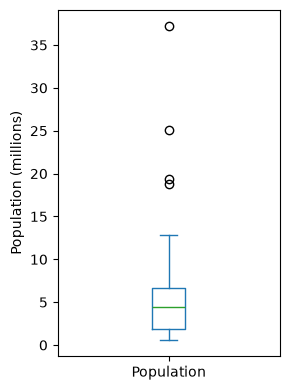

In [19]:
ax = (state['Population']/1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')

plt.tight_layout()
plt.show()

## Frequency Table and Histograms
The `cut` method for _pandas_ data splits the dataset into bins. There are a number of arguments for the method. The following code creates equal sized bins. The method `value_counts` returns a frequency table.

In [20]:
binnedPopulation = pd.cut(state['Population'], 10)
print(binnedPopulation.value_counts())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


In [21]:
# Table 1.5
binnedPopulation.name = 'binnedPopulation'
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by='Population')

groups = []
for group, subset in df.groupby(by='binnedPopulation', observed=False):
    groups.append({
        'BinRange': group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

_Pandas_ also supports histograms for exploratory data analysis.

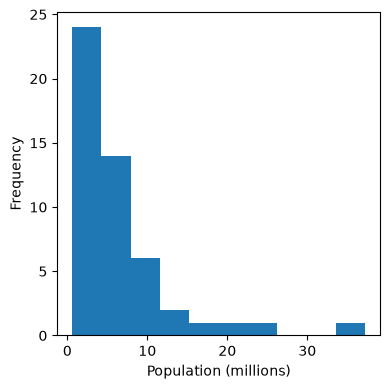

In [22]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

plt.tight_layout()
plt.show()

## Density Estimates
Density is an alternative to histograms that can provide more insight into the distribution of the data points. Use the argument `bw_method` to control the smoothness of the density curve.

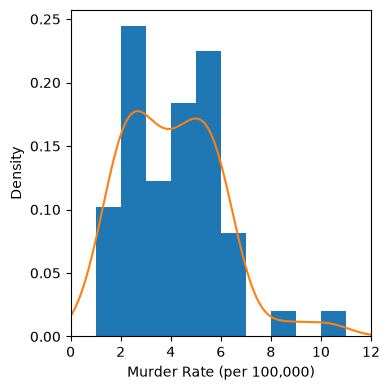

In [23]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], 
                                    bins=range(1,12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

plt.tight_layout()
plt.show()

# Exploring Binary and Categorical Data

In [24]:
# Table 1-6
dfw = pd.read_csv(AIRPORT_DELAYS_CSV)
print(100 * dfw / dfw.values.sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


_Pandas_ also supports bar charts for displaying a single categorical variable.

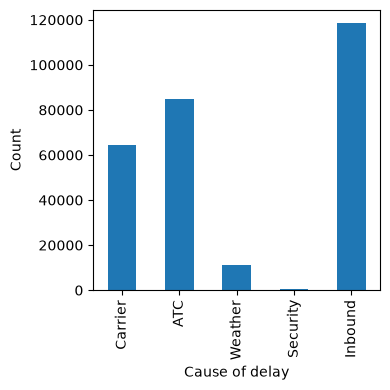

In [25]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Correlation
First read the required datasets

In [26]:
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)

In [27]:
# Table 1-7
# Determine telecommunications symbols
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()
print(telecom)

                   T       CTL       FTR        VZ      LVLT
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


Next we focus on funds traded on major exchanges (sector == 'etf'). 

In [28]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', 
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

Due to the large number of columns in this table, looking at the correlation matrix is cumbersome and it's more convenient to plot the correlation as a heatmap. The _seaborn_ package provides a convenient implementation for heatmaps.

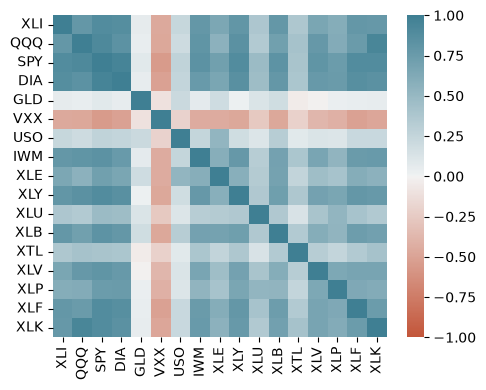

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1, 
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 ax=ax)

plt.tight_layout()
plt.show()

The above heatmap works when you have color. For the greyscale images, as used in the book, we need to visualize the direction as well. The following code shows the strength of the correlation using ellipses.

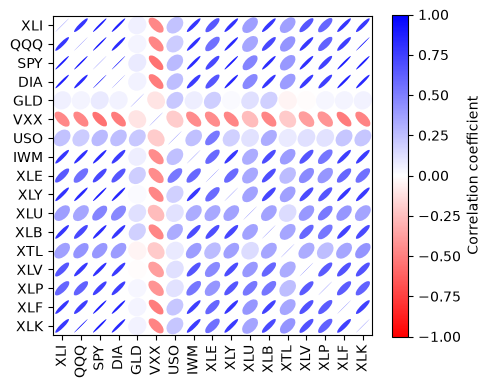

In [30]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize

def plot_corr_ellipses(data, figsize=None, **kwargs):
    ''' https://stackoverflow.com/a/34558488 '''
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect':'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap='bwr_r')
cb = plt.colorbar(m, ax=ax)
cb.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()

## Scatterplots
Simple scatterplots are supported by _pandas_. Specifying the marker as `$\u25EF$` uses an open circle for each point.

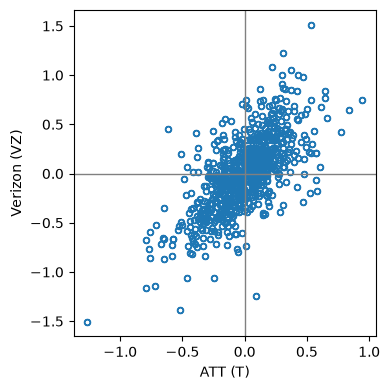

In [31]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

Line2D(_child2)


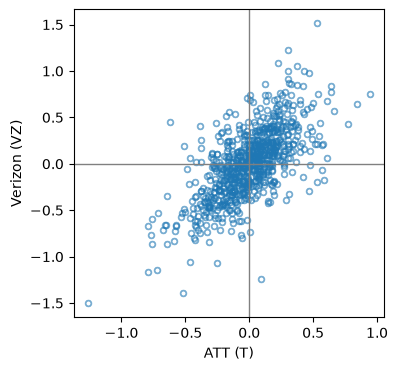

In [32]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$', alpha=0.5)
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
print(ax.axvline(0, color='grey', lw=1))

# Exploring Two or More Variables
Load the kc_tax dataset and filter based on a variety of criteria

In [33]:
kc_tax = pd.read_csv(KC_TAX_CSV)
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) & 
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


## Hexagonal binning and Contours 
### Plotting numeric versus numeric data

If the number of data points gets large, scatter plots will no longer be meaningful. Here methods that visualize densities are more useful. The `hexbin` method for _pandas_ data frames is one powerful approach.

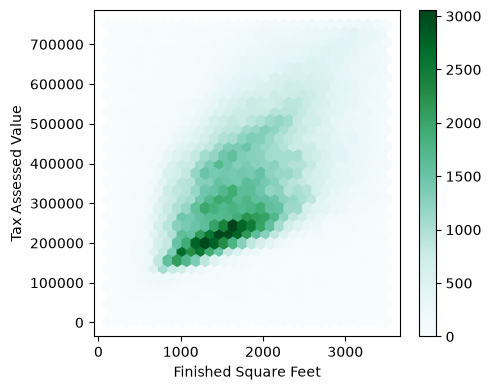

In [34]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

The _seaborn_ kdeplot is a two-dimensional extension of the density plot. The calculation of the 2D-density for the full dataset takes several minutes. It is sufficient to create the visualization with a smaller sample of the dataset. With 10,000 data points, creating the graph takes only seconds. While some details may be lost, the overall shape is preserved. 

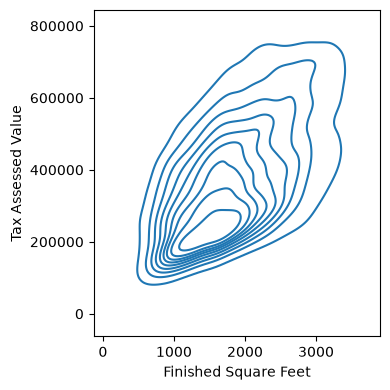

In [35]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

## Two Categorical Variables
Load the `lc_loans` dataset

In [36]:
lc_loans = pd.read_csv(LC_LOANS_CSV)

In [37]:
# Table 1-8(1)
crosstab = lc_loans.pivot_table(index='grade', columns='status', 
                                aggfunc=lambda x: len(x), margins=True)
print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


In [38]:
# Table 1-8(2)
df = crosstab.copy().loc['A':'G',:].astype(float)
df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
print(perc_crosstab)

status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118258  0.654371    0.180409  0.046962  0.028614
G          0.126196  0.614008    0.198396  0.061401  0.007187


## Categorical and Numeric Data
_Pandas_ boxplots of a column can be grouped by a different column.

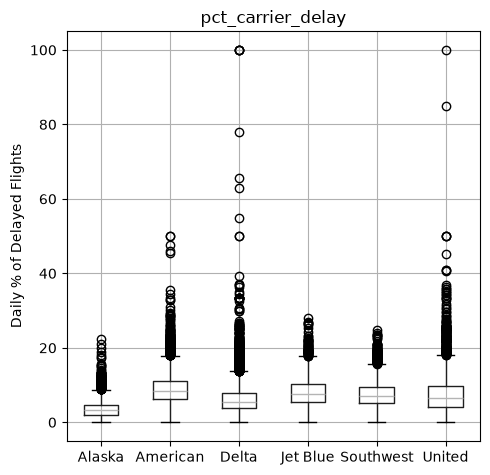

In [39]:
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
airline_stats.head()
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay',
                           figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

plt.tight_layout()
plt.show()

_Pandas_ also supports a variation of boxplots called _violinplot_. 

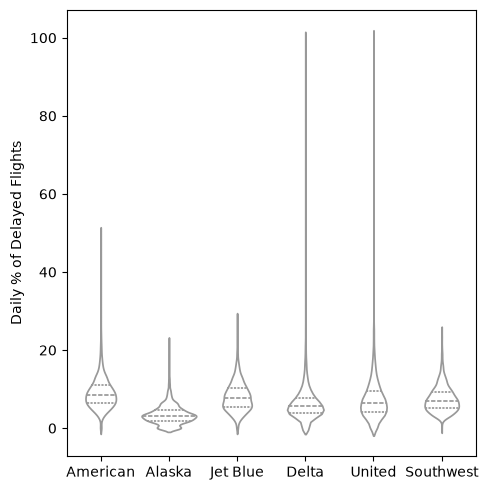

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.tight_layout()
plt.show()

## Visualizing Multiple Variables

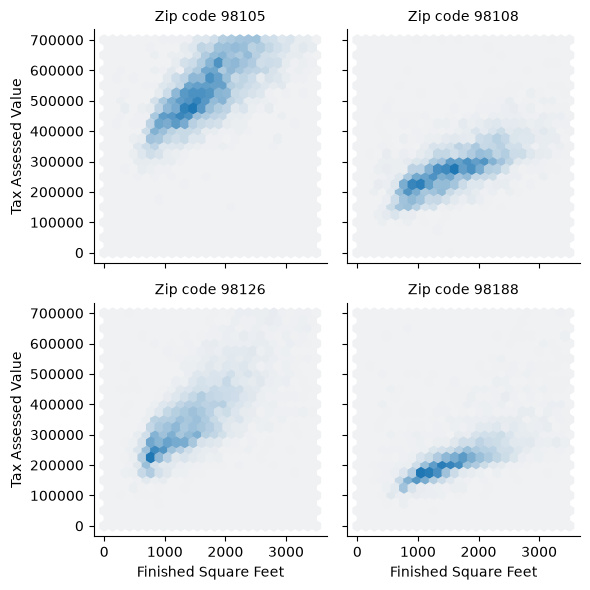

In [41]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', 
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

plt.tight_layout()
plt.show()

# Eksperimen tambahan dan validasi
Sel berikut disusun sebagai pendalaman dan dilengkapi output eksekusi aktual.

## Eksperimen tambahan: ketahanan ukuran pusat dan verifikasi angka
Bagian ini ditulis untuk pendalaman. Mengubah satu nilai menjadi ekstrem menunjukkan sensitivitas mean. Verifikasi memakai hasil hitung independen, bukan sekadar mencetak data.

In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import trim_mean
from statsmodels import robust
DATA = next(p/'data' for p in [Path.cwd(), *Path.cwd().parents] if (p/'data'/'state.csv').exists())
state_check = pd.read_csv(DATA/'state.csv')
x = state_check.Population.to_numpy(dtype=float)
raw_mad = np.median(np.abs(x-np.median(x)))
assert np.isclose(robust.scale.mad(x), raw_mad/0.6744897501960817)
assert np.isclose(x.mean(), 6162876.3)
base = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10, 11.], dtype=float)
changed = base.copy(); changed[-1] = 1000
comparison = pd.DataFrame({label: [a.mean(), np.median(a), trim_mean(a, .1)] for label,a in [('awal',base),('satu nilai ekstrem',changed)]}, index=['mean','median','trimmed mean 10% per ekor'])
display(comparison)
print('Mean populasi:', x.mean(), '| median:', np.median(x))
print('MAD mentah:', raw_mad, '| MAD terskala:', robust.scale.mad(x))

,awal,satu nilai ekstrem
mean,6.5,105.4
median,6.5,6.5
trimmed mean 10% per ekor,6.5,6.5


Mean populasi: 6162876.3 | median: 4436369.5
MAD mentah: 2596702.0 | MAD terskala: 3849876.1459979336


**Cara membaca:** mean berubah tajam akibat satu nilai ekstrem; median dan trimmed mean pada percobaan ini tetap. Ini menunjukkan robust terhadap kontaminasi tertentu, bukan alasan membuang setiap observasi ekstrem.

## Ringkasan hasil yang diperoleh

Mean populasi negara bagian = **6.162.876,3**, median = **4.436.369,5**. Mean lebih tinggi konsisten dengan distribusi yang dipengaruhi negara bagian besar. Pada eksperimen kontaminasi, mean berubah dari 6,5 menjadi 105,4 sementara median dan trimmed mean tetap 6,5.

**Refleksi pembelajaran:** angka di atas berlaku untuk dataset, seed, split, dan versi paket yang dicatat. Reproduksi numerik tidak menggantikan pemahaman asumsi. Penjelasan dan pengembangan disusun dengan bantuan AI, sedangkan asal kode penulis dipertahankan secara eksplisit.